## Configure data frame

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

EXCEL_FILE = "./data/coopers_test_20260429.ods"
FIGURES_DIR = "./figures/"

DATE = EXCEL_FILE.split("_")[-1].split(".")[0]  # extracts the date from the file name

In [2]:
df = pd.read_excel(EXCEL_FILE, sheet_name="Data", header=0)
df = df[df["Name"].notna() & df["Round"].notna()].copy()  # Filter empry rows
df["Round"] = df["Round"].astype(int)
df["Lap_sec"] = df["Lap_sec"].astype(int)
df["Cumulative_sec"] = df["Cumulative_sec"].astype(int)
df.head()

,Name,Round,Lap_Time,Cumulative_Time,Cumulative_sec,Lap_sec
0,Santeri Salomaa,1,01:33.00,01:33.00,93,93
1,Santeri Salomaa,2,01:40.00,03:13.00,193,100
2,Santeri Salomaa,3,01:39.00,04:52.00,292,99
3,Santeri Salomaa,4,01:45.00,06:37.00,397,105
4,Santeri Salomaa,5,01:44.00,08:21.00,501,104


In [3]:
def fmt_sec(sec: float) -> str:
    return f"{int(sec)//60}:{int(sec)%60:02d}"


def sec_formatter(x, _):
    return fmt_sec(x)

## Show basic stats of each runner

In [4]:
names = df["Name"].unique()
rows = []

for name in names:
    sub = df[df["Name"] == name].sort_values("Round")
    laps = sub["Lap_sec"].values
    rows.append(
        {
            "Name": name,
            "Total": fmt_sec(laps.sum()),
            "Avg lap": fmt_sec(laps.mean()),
            "Fastest": f"Rd {sub.loc[sub['Lap_sec'].idxmin(), 'Round']} ({fmt_sec(laps.min())})",
            "Slowest": f"Rd {sub.loc[sub['Lap_sec'].idxmax(), 'Round']} ({fmt_sec(laps.max())})",
            "Std dev (sec)": round(laps.std(), 1),
        }
    )

pd.DataFrame(rows).set_index("Name")

,Total,Avg lap,Fastest,Slowest,Std dev (sec)
Name,,,,,
Santeri Salomaa,11:39,1:39,Rd 1 (1:33),Rd 4 (1:45),3.8
Elias Heikkilä,11:24,1:37,Rd 1 (1:30),Rd 5 (1:41),3.3


## Configurable target paces for distance goals

In [5]:
TARGETS = [
    (96, "3000 m pace (1:36/lap)", "green"),
    (93, "3100 m pace (1:33/lap)", "red"),
]

## Plot lap time per round

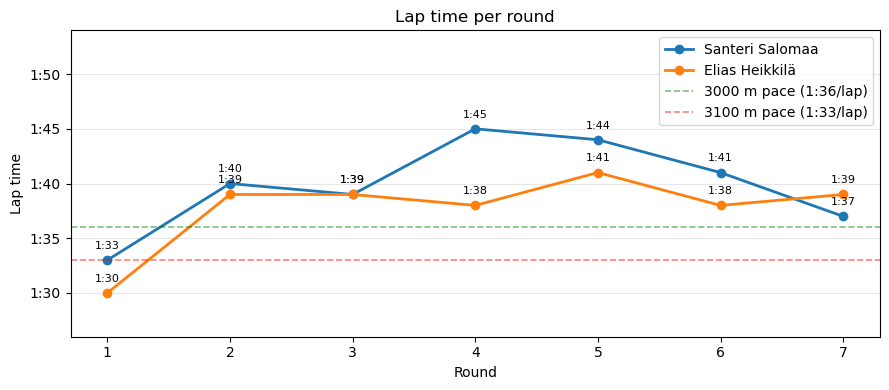

In [6]:
colors = plt.cm.tab10.colors
rounds = sorted(df["Round"].unique())

fig, ax = plt.subplots(figsize=(9, 4))

for i, name in enumerate(names):
    sub = df[df["Name"] == name].sort_values("Round")
    ax.plot(
        sub["Round"],
        sub["Lap_sec"],
        marker="o",
        label=name,
        color=colors[i],
        linewidth=2,
        markersize=6,
    )
    for _, row in sub.iterrows():
        ax.annotate(
            fmt_sec(row["Lap_sec"]),
            (row["Round"], row["Lap_sec"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=8,
        )

for sec, label, color in TARGETS:
    ax.axhline(sec, color=color, linewidth=1.2, linestyle="--", label=label, alpha=0.5)

ax.set_title("Lap time per round")
ax.set_xlabel("Round")
ax.set_ylabel("Lap time")
ax.set_xticks(rounds)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(sec_formatter))
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(86, 114)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}lap_times_{DATE}.png", bbox_inches="tight")
plt.show()

## Plot pace deviation from personal average

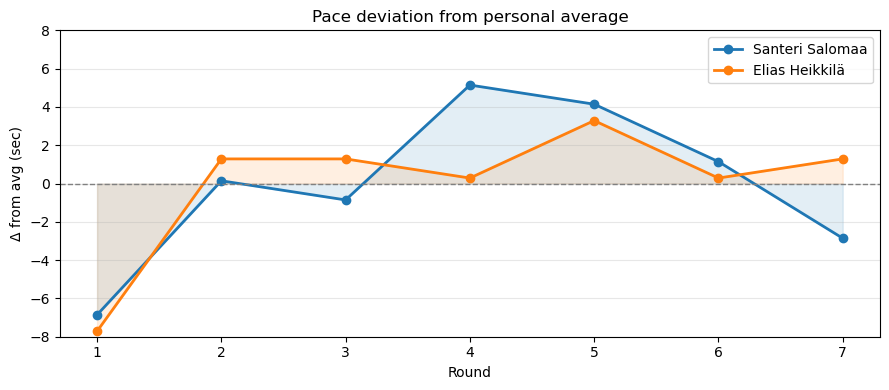

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

for i, name in enumerate(names):
    sub = df[df["Name"] == name].sort_values("Round")
    delta = sub["Lap_sec"] - sub["Lap_sec"].mean()
    ax.plot(
        sub["Round"],
        delta,
        marker="o",
        label=name,
        color=colors[i],
        linewidth=2,
        markersize=6,
    )
    ax.fill_between(sub["Round"], delta, alpha=0.12, color=colors[i])

ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_title("Pace deviation from personal average")
ax.set_xlabel("Round")
ax.set_ylabel("\u0394 from avg (sec)")
ax.set_xticks(rounds)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(-8, 8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}pace_deviation_{DATE}.png", bbox_inches="tight")
plt.show()